# 4 site exact solutions - straddling

Created 21/05/2025

Objectives:
* Find exact solutions with boundary operators of width 4. This time take support to be straddling the symmetry boundary, two sites interior and two sites exterior.

# Package imports

In [11]:
import sys
sys.path.append('../../')

In [12]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [13]:
from itertools import chain, combinations, product
from collections import defaultdict
from functools import reduce
import re

In [14]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

In [15]:
from tqdm import tqdm

In [16]:
import quimb as qu
import quimb.tensor as qtn

In [17]:
#from SPTOptimization.Optimizers.utils import to_npc_array

# Load data

In [18]:
DATA_DIR_1 = r"../../data/finite_cluster_x_transverse_to_product_stacked_cluster_200_site"
DATA_DIR_2 = r"../../data/finite_x_product_stacked_transverse_y_cluster_to_product_200_site"

In [19]:
loaded_data_1 = list()

for local_file_name in os.listdir(DATA_DIR_1):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_1, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_1.append(data)

loaded_data_2 = list()

for local_file_name in os.listdir(DATA_DIR_2):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR_2, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data_2.append(data)

In [20]:
t_parameters = sorted(list(d['paramters']['interpolation'] for d in loaded_data_1))

In [21]:
psi_dict = dict()

In [22]:
for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_1
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b] = quimb_psi

for b in t_parameters:
    mps_psi = next(
        d['wavefunction']
        for d in loaded_data_2
        if d['paramters']['interpolation'] == b
    )

    psi_arrays = list()
    psi_arrays.append(mps_psi.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, mps_psi.L-1):
        psi_arrays.append(mps_psi.get_B(i).to_ndarray())
    psi_arrays.append(mps_psi.get_B(mps_psi.L-1)[..., 0].to_ndarray())

    quimb_psi = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    rounded_b = round(b, 1)
    psi_dict[rounded_b+1] = quimb_psi

# Definitons

In [23]:
MAX_VIRTUAL_BOND_DIM = 8
MAX_INTERMEDIATE_VIRTUAL_BOND_DIM = 2*MAX_VIRTUAL_BOND_DIM
# MPO bond dim?
MAX_MPO_BOND_DIM = 50

SVD_CUTOFF = 1e-3

Define bosonic symmetries. Label by the group element added.

In [24]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [25]:
"""
npc_I = to_npc_array(np_I)
npc_X = to_npc_array(np_X)
npc_Y = to_npc_array(np_Y)
npc_Z = to_npc_array(np_Z)
"""

'\nnpc_I = to_npc_array(np_I)\nnpc_X = to_npc_array(np_X)\nnpc_Y = to_npc_array(np_Y)\nnpc_Z = to_npc_array(np_Z)\n'

In [26]:
def generate_problem_rdm(quimb_psi, symmetry_site_pairs, left_most_symmetry_site,
                         num_symmetry_sites, num_interior_boundary_sites,
                         num_exterior_boundary_sites, antilinear=False):
    # Being careful to conjugate the top tensors.
    q_top = quimb_psi.copy(deep=True)

    for i, s in symmetry_site_pairs:
        if antilinear:
            q_top[i].modify(
                data=q_top[i].data.conj()
            )
        q_top.gate(
            s,
            where=i,
            contract=False,
            inplace=True
        )

    left_exterior_boundary_sites = list(range(
        left_most_symmetry_site - num_exterior_boundary_sites,
        left_most_symmetry_site
    ))

    left_interior_boundary_sites = list(range(
        left_most_symmetry_site,
        left_most_symmetry_site + num_interior_boundary_sites
    ))

    left_boundary_sites = (
        left_exterior_boundary_sites
        + left_interior_boundary_sites
    )

    right_most_symmetry_site = left_most_symmetry_site + num_symmetry_sites - 1

    right_interior_boundary_sites = list(range(
        right_most_symmetry_site - num_interior_boundary_sites+1,
        right_most_symmetry_site+1
    ))

    right_exterior_boundary_sites = list(range(
        right_most_symmetry_site+1,
        right_most_symmetry_site + num_exterior_boundary_sites+1
    ))
    
    right_boundary_sites = (
        right_interior_boundary_sites
        + right_exterior_boundary_sites
    )

    indices_to_map = list(chain(left_boundary_sites, right_boundary_sites))

    index_mapping = {f'k{i}': f'b{i}' for i in indices_to_map}

    q_bottom = (
        quimb_psi
        .copy()
        .reindex(index_mapping, inplace=True)
        .conj()
    )

    sites_to_contract = {
        'left': list(range(left_most_symmetry_site-num_exterior_boundary_sites)),
        'middle': list(range(
            left_most_symmetry_site+num_interior_boundary_sites,
            right_most_symmetry_site - num_interior_boundary_sites+1
        )),
        'right': list(range(
            right_most_symmetry_site + num_exterior_boundary_sites+1,
            quimb_psi.L
        ))
    }

    tags_to_contract = {
        k: [f'I{i}' for i in v]
        for k, v in sites_to_contract.items()
    }

    tn = (q_top & q_bottom)

    tnc = tn.contract()

    first_fuse_maps = [
        ('k_left_in', (f'k{i}' for i in left_interior_boundary_sites)),
        ('k_left_out', (f'k{i}' for i in left_exterior_boundary_sites)),
        ('b_left_in', (f'b{i}' for i in left_interior_boundary_sites)),
        ('b_left_out', (f'b{i}' for i in left_exterior_boundary_sites)),
        ('k_right_in', (f'k{i}' for i in right_interior_boundary_sites)),
        ('k_right_out', (f'k{i}' for i in right_exterior_boundary_sites)),
        ('b_right_in', (f'b{i}' for i in right_interior_boundary_sites)),
        ('b_right_out', (f'b{i}' for i in right_exterior_boundary_sites)),
    ]

    second_fuse_maps = [
        ('k_left', ('k_left_in', 'k_left_out')),
        ('b_left', ('b_left_in', 'b_left_out')),
        ('k_right', ('k_right_in', 'k_right_out')),
        ('b_right', ('b_right_in', 'b_right_out'))
    ]

    (
        tnc
        .fuse(first_fuse_maps, inplace=True)
        .fuse(second_fuse_maps, inplace=True)
    )

    return tnc

## Optimisation functions

In [27]:
def solve_for_boundary_operators(rdm, num_iters=20):
    scores = list()

    left_inds = [
        'k_left',
        'b_left'
    ]

    right_inds=[
        'k_right',
        'b_right'
    ]
    # Hard code warning
    u_left = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=left_inds,
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (16, 16),
        inds=right_inds,
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_rdm = (rdm & u_left).contract()
        data = right_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds=right_inds)
        
        left_rdm = (rdm & u_right).contract()
        data = left_rdm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds=left_inds)

    return (u_left, u_right), scores

## SPT functions

In [154]:
def in_local_conjugate_left_defect_operator(defect_operator):
    fuse_map = {
        'k_left': ('k_left_in', 'k_left_out'),
        'b_left': ('b_left_in', 'b_left_out')
    }
    
    shape_map = {
        'k_left': (4, 4),
        'b_left': (4, 4)
    }
    
    ut = defect_operator.unfuse(fuse_map, shape_map)

    split_t = qtn.tensor_split(ut,['k_left_in', 'b_left_in'], ltags='in')
    split_t['in'] = split_t['in'].conj()
    out_t = split_t ^...
    out_t.drop_tags('in')
    out_t = out_t.fuse(fuse_map)

    return out_t

In [104]:
def in_local_conjugate_right_defect_operator(defect_operator):
    fuse_map = {
        'k_right': ('k_right_in', 'k_right_out'),
        'b_right': ('b_right_in', 'b_right_out')
    }
    
    shape_map = {
        'k_right': (4, 4),
        'b_right': (4, 4)
    }
    
    ut = defect_operator.unfuse(fuse_map, shape_map)

    split_t = qtn.tensor_split(ut,['k_right_in', 'b_right_in'], ltags='in')
    split_t['in'] = split_t['in'].conj()
    out_t = split_t ^...
    out_t.drop_tags('in')
    out_t = out_t.fuse(fuse_map)

    return out_t

In [115]:
def in_local_conjugate_defect_operator(defect_operator):
    if set(defect_operator.inds) == {'k_left', 'b_left'}:
        return in_local_conjugate_left_defect_operator(defect_operator)
    elif set(defect_operator.inds) == {'k_right', 'b_right'}:
        return in_local_conjugate_right_defect_operator(defect_operator)
    else:
        raise ValueError

## SPT extraction functions

In [34]:
# Boolean indicates if the symmetry is anti-linear or not.
symmetry_actions = [
    ([np_I, np_I], False),
    ([np_X, np_I], False),
    ([np_I, np_X], True),
    ([np_X, np_X], True)
]

In [35]:
symmetry_labels = [
    'I-I',
    'X-I',
    'I-XK',
    'X-XK'
]

In [36]:
identity_element = 'I-I'

In [37]:
e, a, b, c = symmetry_labels

In [38]:
group_products = [
    (a, a, e),
    (b, b, e),
    (c, c, e),
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (b, c, a),
    (c, b, a),
]

In [39]:
group_products_dict = {
    (a,b): c for a,b,c in group_products
}

In [40]:
def multi_kron(arrays):
    return reduce(lambda X, Y: np.kron(X, Y), arrays)

In [41]:
symmetry_actions_dict = {
    'I-I': (np.identity(16), False),
    'X-I': (multi_kron([np_X, np_I, np_X, np_I]), False),
    'I-XK': (multi_kron([np_I, np_X, np_I, np_X]), True),
    'X-XK': (multi_kron([np_X, np_X, np_X, np_X]), True)
}

In [42]:
antilinear_dict = {
    e: False,
    a: False,
    b: True,
    c: True
}

In [45]:
np_I_4 = np.identity(16)

In [135]:
test_t = qtn.Tensor(np_I_4, inds=['a','b'])

In [136]:
test_t

Tensor(shape=(16, 16), inds=('a', 'b'), tags=oset([]))

In [146]:
def transpose_defect_operator(t):
    if set(t.inds) == {'b_left', 'k_left'}:
        return t.transpose('b_left', 'k_left').data
    elif set(t.inds) == {'b_right', 'k_right'}:
        return t.transpose('b_right', 'k_right').data
    else:
        raise ValueError

In [152]:
# This code might be assuming the group is Abelian? Check Kapustin index formula in nonAbelian case.
def get_proj_rep_phase(rho, u_g, u_h, u_gh, g_symmetry_label):
    g_sym, antilinear = symmetry_actions_dict[g_symmetry_label]

    if antilinear:
        u_h = in_local_conjugate_defect_operator(u_h)

    u_g = transpose_defect_operator(u_g)
    u_h = transpose_defect_operator(u_h)
    u_gh = transpose_defect_operator(u_gh)

    m = (
        (u_gh.conj().T)
        @ u_h
        @ u_g
        @ rho
    )
    exp = np.trace(m)

    out = exp/np.abs(exp)

    return out

In [150]:
# Duplicate definition here...!
def get_proj_rep_phases(rho, unitaries):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    unitaries_dict['I-I'] = qtn.Tensor(np_I_4, inds=unitaries[0].inds)

    out_phases = list()
    for a, b, c in group_products:
        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            a
        )

        out_phases.append(phase)

    return out_phases

## Cocycle checks

In [119]:
def omega_lookup(proj_rep_phases_array, g, h):
    if (g == identity_element) or (h == identity_element):
        return np.ones(shape=proj_rep_phases_array.shape[:-1], dtype=np.complex128)
    index = next(
        i for i, (a,b,c) in enumerate(group_products)
        if (a,b) == (g,h)
    )

    return proj_rep_phases_array[..., index]

In [120]:
def cocyle_check(proj_rep_phases_array, g, h, k, twisted=False):
    X = omega_lookup(proj_rep_phases_array, h, k)
    if antilinear_dict[g] and twisted:
        X = X.conj()

    cocycle_array = (
        X*omega_lookup(proj_rep_phases_array, g, group_products_dict[(h,k)])
        /(
            omega_lookup(proj_rep_phases_array, g, h)
            *omega_lookup(proj_rep_phases_array, group_products_dict[(g,h)], k)
        )
    )

    return cocycle_array

In [121]:
def check_cocycle_equation(proj_rep_phases_array, twisted=False):
    arrays = list()

    for g,h,k in product(symmetry_labels[1:], repeat=3):
        arrays.append(cocyle_check(proj_rep_phases_array, g,h,k, twisted))

    out = np.stack(arrays, axis=-1)

    return out

# Calculate boundary operators

In [122]:
num_interior_boundary_sites=2
num_exterior_boundary_sites=2
left_most_symmetry_site=60
num_symmetry_sites=80

symmetry_sites = list(range(
    left_most_symmetry_site,
    left_most_symmetry_site+num_symmetry_sites
))

In [55]:
num_iterations = 3

In [56]:
results_dict = dict()

for k1, psi in tqdm(psi_dict.items()):
    for k2, (bs, antilinear) in enumerate(symmetry_actions[1:], start=1):
        symmetry_site_pairs = (
            [(i, bs[0]) for i in range(left_most_symmetry_site, left_most_symmetry_site+num_symmetry_sites, 2)]
            + [(i, bs[1]) for i in range(left_most_symmetry_site+1, left_most_symmetry_site+num_symmetry_sites+1, 2)]
        )
    
        rdm = generate_problem_rdm(
            psi,
            symmetry_site_pairs,
            left_most_symmetry_site,
            num_symmetry_sites,
            num_interior_boundary_sites,
            num_exterior_boundary_sites,
            antilinear=antilinear
        )
    
        (u_left, u_right), scores = solve_for_boundary_operators(
            rdm,
            num_iters=num_iterations
        )
    
        results_dict[(k1, k2)] = (u_left, u_right), scores

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [01:06<00:00,  3.17s/it]


### Check results

In [124]:
t_params = np.round(np.linspace(0, 2, 21), 1)

In [125]:
t_params

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ])

In [126]:
scores = list()
for t in t_params:

    scores.append([results_dict[(t, i)][1][-1] for i in [1,2,3]])

scores = np.array(scores)

In [127]:
colors = [
    'tab:blue',
    'tab:orange',
    'tab:green'
]   

Text(0.5, 0.98, 'Final overlap $\\vert c \\vert$ with symmetry $g$ as a function of $B$')

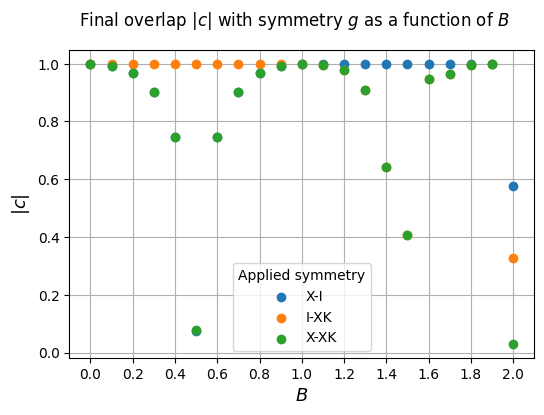

In [128]:
fig, ax = plt.subplots(figsize=(6,4))

for j, (col, label) in enumerate(zip(colors, symmetry_labels[1:])):
    plt.scatter(
        t_params,
        scores[:, j],
        color=col,
        label = label
    )

ax.xaxis.set_major_locator(
    matplotlib.ticker.MultipleLocator(0.2)
)

#ax.set_yscale('log')

ax.grid()
ax.grid(
    which='minor',
    axis='y',
    linestyle='--',
    zorder=-1e10
)
ax.set_axisbelow(True)

ax.set_ylabel(r'$\vert c\vert$', fontsize=13)
ax.set_xlabel('$B$', fontsize=13)

ax.legend(loc='lower center', title='Applied symmetry')

fig.suptitle(r'Final overlap $\vert c \vert$ with symmetry $g$ as a function of $B$')

#fig.savefig(r'plots/ed_cost_function_from_svd_bosonic.png', dpi=200)

Why are the boundary operator scores so good...?

In [155]:
proj_rep_phases = list()

for t in tqdm(t_params):
    psi = psi_dict[t]

    rdm = generate_problem_rdm(
        psi,
        [],
        left_most_symmetry_site,
        num_symmetry_sites,
        num_interior_boundary_sites,
        num_exterior_boundary_sites,
    )

    left_rdm = (
        rdm
        .trace('b_right', 'k_right')
        .transpose('k_left', 'b_left')
        .data
    )
    right_rdm = (
        rdm
        .trace('b_left', 'k_left')
        .transpose('k_right', 'b_right')
        .data
    )

    unitary_pairs = [results_dict[(t, i)][0] for i in [1,2,3]]
    left_unitaries, right_unitaries = zip(*unitary_pairs)

    left_phases = get_proj_rep_phases(left_rdm, left_unitaries)
    right_phases = get_proj_rep_phases(right_rdm, right_unitaries)

    proj_rep_phases.append([left_phases, right_phases])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:23<00:00,  1.11s/it]


In [156]:
proj_rep_phases = np.array(proj_rep_phases)

In [157]:
proj_rep_phases.shape

(21, 2, 9)

In [158]:
np.round(proj_rep_phases, 3)

array([[[-0.706-0.708j,  1.   +0.j   ,  1.   -0.j   , -0.056+0.998j,
         -0.667-0.745j, -0.667+0.745j, -0.056-0.998j, -0.667-0.745j,
         -0.056-0.998j],
        [-0.706+0.708j,  1.   -0.j   ,  1.   -0.j   , -0.056-0.998j,
         -0.667+0.745j, -0.667-0.745j, -0.056+0.998j, -0.667+0.745j,
         -0.056+0.998j]],

       [[ 0.927+0.376j,  1.   -0.j   ,  1.   -0.j   ,  0.598-0.801j,
          0.253-0.967j,  0.253+0.967j,  0.598+0.801j,  0.253-0.967j,
          0.598+0.801j],
        [ 0.927-0.376j,  1.   +0.j   ,  1.   +0.j   ,  0.598+0.801j,
          0.253+0.967j,  0.253-0.967j,  0.598-0.801j,  0.253+0.967j,
          0.598-0.801j]],

       [[-0.828+0.56j ,  1.   +0.j   ,  1.   +0.j   ,  0.709+0.705j,
         -0.193-0.981j, -0.193+0.981j,  0.709-0.705j, -0.193-0.981j,
          0.709-0.705j],
        [-0.828-0.56j ,  1.   -0.j   ,  1.   +0.j   ,  0.709-0.705j,
         -0.193+0.981j, -0.193-0.981j,  0.709+0.705j, -0.193+0.981j,
          0.709+0.705j]],

       [[ 0.985+

In [159]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=False)

In [160]:
np.max(np.abs(cocycle_check_array - 1))

1.9971378470489096

In [161]:
cocycle_check_array = check_cocycle_equation(proj_rep_phases, twisted=True)

In [162]:
np.max(np.abs(cocycle_check_array - 1))

1.999997462215287